#### Use inset_axes() to pin multiple histograms on a map.
- Use Cartopy to plot the map.
- Define locations (latitude, longitude) to pin the histograms.
- Create individual histograms at each location.
- median and percentile ranges for projected percentage changes in TC frequency, category 4–5 TC frequency
    - For TC frequency, the 5th–95th-percentile range across published estimates is shown.
    - For category 4–5, TC frequency, TC intensity, and TC near-storm rain rates the 10th–90th-percentile range is shown.
- Overlay the histograms on the map using - ax.inset_axes() or OffsetImage from mpl_toolkits.axes_grid1

Ming Ge April 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import tc_helping
from importlib import reload
reload(tc_helping)
from tc_helping import rd_HR_SH

In [2]:
# plot 6 custom boxplots in a single figure 
def box_custom_2_inset(ax, data1, data2, q1, q3, title_s):
    '''
    q1: two Q1 correspondent to data1, data2
    q3: two Q3 correspondent to data1, data2
    '''
    # Compute custom statistics for data1 (with whiskers equal to Q1 and Q3)
    q1_1 = np.percentile(data1, q1[0])
    q3_1 = np.percentile(data1, q3[0])
    med1 = np.median(data1)
    box1 = {
        'med': med1,
        'q1': q1_1,
        'q3': q3_1,
        'whislo': q1_1,  # lower whisker set to Q1
        'whishi': q3_1,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    # Compute custom statistics for data2
    q1_2 = np.percentile(data2, q1[1])
    q3_2 = np.percentile(data2, q3[1])
    med2 = np.median(data2)
    box2 = {
        'med': med2,
        'q1': q1_2,
        'q3': q3_2,
        'whislo': q1_2,  # lower whisker set to Q1
        'whishi': q3_2,  # upper whisker set to Q3
        'fliers': []     # no outliers
    }

    #  Use patch_artist=True so that boxes are drawn as Patch objects
    ax.bxp([box1, box2], patch_artist=True,
       boxprops={'facecolor': 'grey', 'alpha':0.5}, 
                 #'color': 'lightsteelblue'},
       #whiskerprops={'color': 'grey'},
       #capprops={'color': 'grey'},
       medianprops={'color': 'black'})

    # Add a horizontal line at y=0
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
    # Set the font size of the y-axis tick labels
    ax.tick_params(axis='y', labelsize=6, pad=0)  # Adjust 'labelsize' as needed

    ax.set_xticklabels(["TC Freq", "Cat 4-5"], fontsize=8)
    #ax.set_yticklabels(fontsize=8)
    ax.set_title(title_s)
    ax.set_ylabel("% Change", labelpad=0, fontsize=8)

In [3]:
dir_plot = '/glade/campaign/mmm/c3we/mingge/TC/PLOT/'
dir_hr   = '/glade/campaign/mmm/c3we/done/pcast/CESM_HR/'
dir_o    = '/glade/campaign/mmm/c3we/mingge/TC/DATA/'

#  time period
year_s = 1940
year_e = 2100

n_year = year_e - year_s + 1

# 5 Buckley Cyclone Regions and New Zealand
region_s = ['BC 1', 'BC 2', 'BC 3','BC 4','BC 5', 'New Zealand']
lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-27, -9,  -9,  -9, -22, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 
n_region = len(lat_s_1d)

n_mem = 10

In [4]:
%%time

slope_3d = np.zeros((n_region, n_mem, 2))
xx = range(year_s, year_e+1)
slope2percentage = n_year*100

for nr in range(n_region): 
    if nr == n_region - 1:
        print(' New Zealand ' )
    else:
        print(' Australia Buckley Cyclone Region ' + str(nr + 1))
        
    lat_s = lat_s_1d[nr]
    lat_e = lat_e_1d[nr]
    lon_s = lon_s_1d[nr]
    lon_e = lon_e_1d[nr]
    lon_cen = (lon_s+lon_e)*0.5
    proj   = ccrs.PlateCarree(central_longitude=lon_cen)
    extent = [lon_s, lon_e, lat_s, lat_e]
    
    time_s = str(year_s) + '-' + str(year_e)
    data_HR_BCR1 = rd_HR_SH(dir_hr, year_s, year_e, proj, lon_cen, extent, False, cmap='new_cmap_australia', cat_color = 'CAT_COLORS_australia', cat_name='CAT_australia', is_GreaterCat3=True)
    # we use tc_count [ n_mem, n_year, 0 , :]   
    #print(data_HR_BCR1.shape) # (n_mem, n_year, n_var, cat)
    # TC frequency (n_mem, n_year, [cat0, cat4-5])
    data_3d =  data_HR_BCR1[:,:,0,:] #((10, 161, 2))
    for nm in range(n_mem):
        for nv in range(2):
            slope_3d[nr, nm, nv] = np.polyfit(xx, data_3d[nm,:,nv], 1)[0]
     
slope_3d = slope_3d*slope2percentage

 Australia Buckley Cyclone Region 1
 Australia Buckley Cyclone Region 2
 Australia Buckley Cyclone Region 3
 Australia Buckley Cyclone Region 4
 Australia Buckley Cyclone Region 5
 New Zealand 
CPU times: user 1min 49s, sys: 889 ms, total: 1min 50s
Wall time: 1min 59s


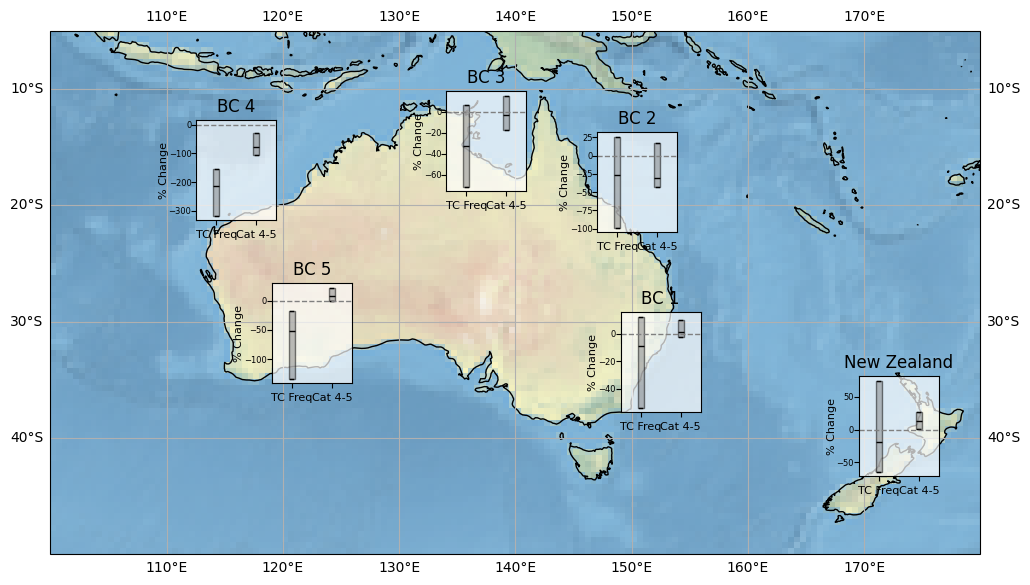

In [5]:
# Map locations (latitude, longitude)
#locations = [(40, -105), (35, -100), (42, -95)]  # (lat, lon)
latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d))/2).tolist()

locations = list(zip(latc_1d, lonc_1d))

# Plot the map
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, -50, -5], crs=ccrs.PlateCarree())

# Add map features
ax.stock_img()
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot histograms at different locations
for nr in range(n_region): 
    lat, lon = locations[nr]
    # Create an inset axes for each histogram
    inset_ax = inset_axes(ax, width=0.8, height=1.0, 
                          loc='center',
                          # Use absolute positioning
                          bbox_to_anchor=(lon, lat, 0, 0),
                          bbox_transform=ax.transData, borderpad=0)
    # Set axes background to some transparent
    inset_ax.patch.set_alpha(0.7)
    
    data_1 = slope_3d[nr, :, 0]
    data_2 = slope_3d[nr, :, 1]

    # Plotting:
    # data_1: TC frequency 5%-95%,
    # data_2: Cat 4-5 frequency: 10%-90%
    box_custom_2_inset(inset_ax, data_1, data_2, [5,10], [95,90], region_s[nr])
    
#plt.title("boxplots Pinned on Different Regions of the Map")
